In [2]:
import cv2
import numpy as np 
from matplotlib import pyplot as plt
import math



In [3]:
img = cv2.imread('data/fresh\Screen Shot 2018-06-08 at 4.59.49 PM.png')
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


In [5]:
img_2d = image.reshape((-1, 3))
img_2d = np.float32(img_2d)

print(img_2d.shape)

(167232, 3)


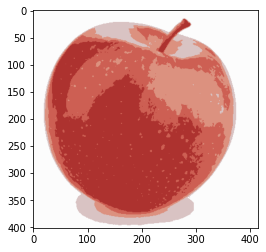

In [11]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 300, 0.3)

k = 5
element1, labels, centers = cv2.kmeans(img_2d, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
labels = labels.flatten()
segmented = centers[labels.flatten()]

segmented = segmented.reshape(image.shape)
plt.imshow(segmented)
plt.show()

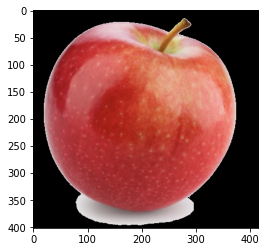

In [12]:
height, width = image.shape[:2]
    
maxx = segmented.max()

r,g,b = cv2.split(image)
r_f = r.flatten()
g_f = g.flatten()
b_f = b.flatten()

er, eg, eb = cv2.split(segmented)

er_f = er.flatten()
eg_f = eg.flatten()
eb_f = eb.flatten()

for i in range(len(er_f)):
    if (er_f[i] == maxx  or eg_f[i] == maxx or eb_f[i] == maxx):
        r_f[i] = 0
        g_f[i] = 0
        b_f[i] = 0


new_r = np.reshape(r_f, (height, width))
new_g = np.reshape(g_f, (height, width))
new_b = np.reshape(b_f, (height, width))


removed = cv2.merge((new_r,new_g,new_b))

plt.imshow(removed)
plt.show()
